# Importing libraries

In [2]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Dataset Loading

In [3]:
rom google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv("/content/drive/MyDrive/Crop_yield_prediction/yield_df.csv")

# DATA INSPECTION




In [5]:
print(df.shape)

(28242, 8)


In [6]:
print(df.columns)

Index(['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield',
       'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp'],
      dtype='object')


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  object 
 2   Item                           28242 non-null  object 
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 1.7+ MB
None


In [8]:
print(df.describe())

         Unnamed: 0          Year    hg/ha_yield  \
count  28242.000000  28242.000000   28242.000000   
mean   14120.500000   2001.544296   77053.332094   
std     8152.907488      7.051905   84956.612897   
min        0.000000   1990.000000      50.000000   
25%     7060.250000   1995.000000   19919.250000   
50%    14120.500000   2001.000000   38295.000000   
75%    21180.750000   2008.000000  104676.750000   
max    28241.000000   2013.000000  501412.000000   

       average_rain_fall_mm_per_year  pesticides_tonnes      avg_temp  
count                    28242.00000       28242.000000  28242.000000  
mean                      1149.05598       37076.909344     20.542627  
std                        709.81215       59958.784665      6.312051  
min                         51.00000           0.040000      1.300000  
25%                        593.00000        1702.000000     16.702500  
50%                       1083.00000       17529.440000     21.510000  
75%                       1

In [9]:
print(df.isnull().sum())

Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64


In [10]:
print(df.describe())

         Unnamed: 0          Year    hg/ha_yield  \
count  28242.000000  28242.000000   28242.000000   
mean   14120.500000   2001.544296   77053.332094   
std     8152.907488      7.051905   84956.612897   
min        0.000000   1990.000000      50.000000   
25%     7060.250000   1995.000000   19919.250000   
50%    14120.500000   2001.000000   38295.000000   
75%    21180.750000   2008.000000  104676.750000   
max    28241.000000   2013.000000  501412.000000   

       average_rain_fall_mm_per_year  pesticides_tonnes      avg_temp  
count                    28242.00000       28242.000000  28242.000000  
mean                      1149.05598       37076.909344     20.542627  
std                        709.81215       59958.784665      6.312051  
min                         51.00000           0.040000      1.300000  
25%                        593.00000        1702.000000     16.702500  
50%                       1083.00000       17529.440000     21.510000  
75%                       1

In [11]:
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [12]:
df.tail()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
28237,28237,Zimbabwe,"Rice, paddy",2013,22581,657.0,2550.07,19.76
28238,28238,Zimbabwe,Sorghum,2013,3066,657.0,2550.07,19.76
28239,28239,Zimbabwe,Soybeans,2013,13142,657.0,2550.07,19.76
28240,28240,Zimbabwe,Sweet potatoes,2013,22222,657.0,2550.07,19.76
28241,28241,Zimbabwe,Wheat,2013,22888,657.0,2550.07,19.76


In [13]:
df.sample(10)

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
23977,23977,Rwanda,Yams,1993,53333,1212.0,127.40,19.53
22400,22400,Pakistan,Maize,2001,17631,494.0,11871.00,25.18
13866,13866,India,Cassava,2010,347555,1083.0,40093.69,27.68
11483,11483,India,Sorghum,1995,8235,1083.0,61257.00,26.04
156,156,Algeria,Sorghum,2001,27750,89.0,710.11,18.13
10631,10631,India,Soybeans,1990,10145,1083.0,75000.00,26.63
10166,10166,Honduras,Sweet potatoes,1990,64286,1976.0,9880.07,24.53
14962,14962,Indonesia,Potatoes,2001,148495,2702.0,1597.00,26.81
5740,5740,Canada,Wheat,1996,24304,537.0,35240.80,6.88
8230,8230,Egypt,Sweet potatoes,2000,273327,51.0,4931.00,21.49


In [14]:
df.describe()

,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,14120.500000,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,8152.907488,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,7060.250000,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,14120.500000,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,21180.750000,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,28241.000000,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


In [15]:
df['Item'].unique()

array(['Maize', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Wheat',
       'Cassava', 'Sweet potatoes', 'Plantains and others', 'Yams'],
      dtype=object)

In [16]:
print (df.dtypes)

Unnamed: 0                         int64
Area                              object
Item                              object
Year                               int64
hg/ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object


In [17]:
print(df['Item'].value_counts())


Item
Potatoes                4276
Maize                   4121
Wheat                   3857
Rice, paddy             3388
Soybeans                3223
Sorghum                 3039
Sweet potatoes          2890
Cassava                 2045
Yams                     847
Plantains and others     556
Name: count, dtype: int64


In [18]:
print(df.isnull().sum())

Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64


In [19]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [20]:
print(df.memory_usage(deep=True))

Index                                132
Unnamed: 0                        225936
Area                             1587609
Item                             1611564
Year                              225936
hg/ha_yield                       225936
average_rain_fall_mm_per_year     225936
pesticides_tonnes                 225936
avg_temp                          225936
dtype: int64


In [21]:
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"Column names: {', '.join(df.columns)}")
print(f"Missing cells: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

Total rows: 28242
Total columns: 8
Column names: Unnamed: 0, Area, Item, Year, hg/ha_yield, average_rain_fall_mm_per_year, pesticides_tonnes, avg_temp
Missing cells: 0
Duplicate rows: 0


In [22]:
print(df["hg/ha_yield"].describe())

count     28242.000000
mean      77053.332094
std       84956.612897
min          50.000000
25%       19919.250000
50%       38295.000000
75%      104676.750000
max      501412.000000
Name: hg/ha_yield, dtype: float64


In [23]:
crop_yield = df.groupby("Item")["hg/ha_yield"].mean().sort_values(ascending=False)

print(crop_yield)

Item
Potatoes                199801.549579
Cassava                 150479.466993
Sweet potatoes          119057.793772
Yams                    114140.345927
Plantains and others    106041.320144
Rice, paddy              40730.434770
Maize                    36310.070614
Wheat                    30116.267825
Sorghum                  18635.777229
Soybeans                 16731.092771
Name: hg/ha_yield, dtype: float64


# DATA CLEANING

In [24]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [25]:
print(df.columns)

Index(['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp'],
      dtype='object')


In [26]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 2310


In [27]:
df.drop_duplicates(inplace=True)

In [28]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [29]:
print(df.isnull().sum())

Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64


Data Preprocessing

In [30]:
X = df.drop("hg/ha_yield", axis=1)

y = df["hg/ha_yield"]

In [31]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (25932, 6)
y shape: (25932,)


In [32]:
X = pd.get_dummies(
    X,
    columns=["Area", "Item"],
    drop_first=True
)

In [33]:
print(X.shape)
print(X.head())

(25932, 113)
   Year  average_rain_fall_mm_per_year  pesticides_tonnes  avg_temp  \
0  1990                         1485.0              121.0     16.37   
1  1990                         1485.0              121.0     16.37   
2  1990                         1485.0              121.0     16.37   
3  1990                         1485.0              121.0     16.37   
4  1990                         1485.0              121.0     16.37   

   Area_Algeria  Area_Angola  Area_Argentina  Area_Armenia  Area_Australia  \
0         False        False           False         False           False   
1         False        False           False         False           False   
2         False        False           False         False           False   
3         False        False           False         False           False   
4         False        False           False         False           False   

   Area_Austria  ...  Area_Zimbabwe  Item_Maize  Item_Plantains and others  \
0         Fal

# EXPLORATY DATA ANALYSIS

In [34]:
print(df["Item"].value_counts())

Item
Potatoes                3956
Maize                   3824
Wheat                   3539
Rice, paddy             3091
Soybeans                2940
Sorghum                 2770
Sweet potatoes          2593
Cassava                 1889
Yams                     774
Plantains and others     556
Name: count, dtype: int64


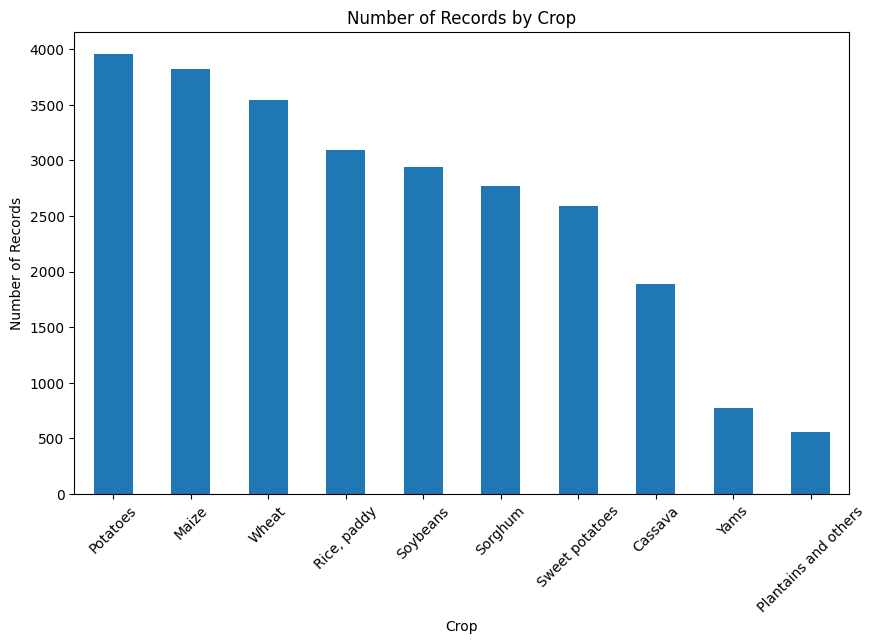

In [35]:
plt.figure(figsize=(10,6))

df["Item"].value_counts().plot(kind="bar")

plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.title("Number of Records by Crop")

plt.xticks(rotation=45)
plt.show()

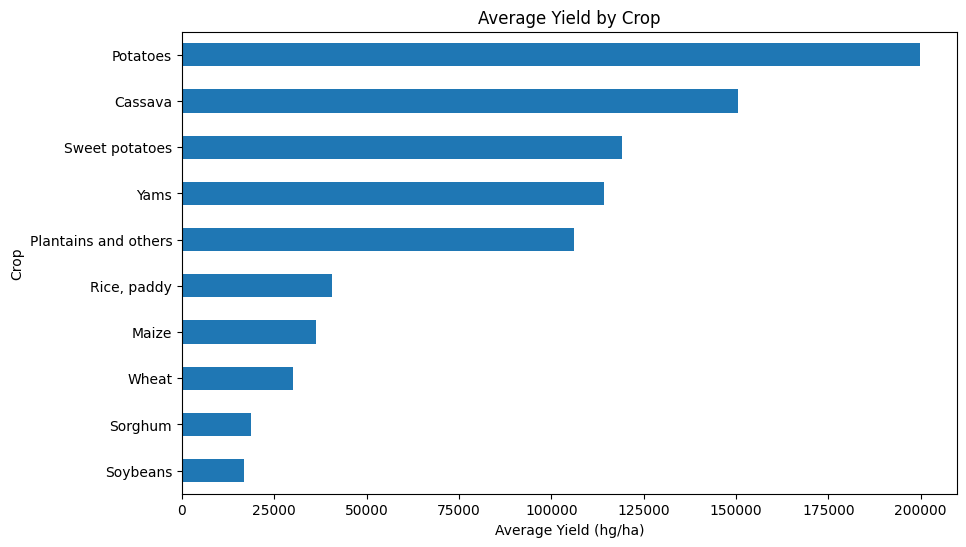

In [36]:
plt.figure(figsize=(10,6))

crop_yield.sort_values().plot(kind="barh")

plt.xlabel("Average Yield (hg/ha)")
plt.ylabel("Crop")
plt.title("Average Yield by Crop")

plt.show()

In [37]:
highest_crop = crop_yield.idxmax()
highest_yield = crop_yield.max()

print("Highest yielding crop:", highest_crop)
print("Average yield:", highest_yield, "hg/ha")

Highest yielding crop: Potatoes
Average yield: 199801.54957904585 hg/ha


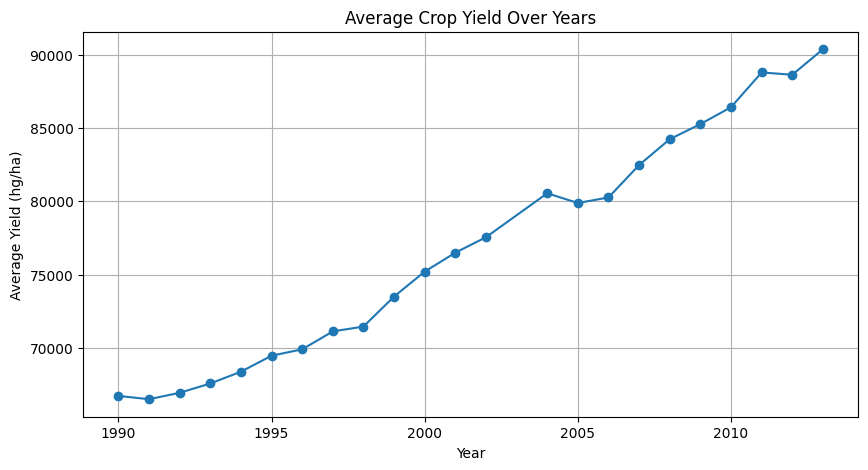

In [38]:
year_yield = df.groupby("Year")["hg/ha_yield"].mean()

plt.figure(figsize=(10,5))

plt.plot(year_yield.index, year_yield.values, marker="o")

plt.xlabel("Year")
plt.ylabel("Average Yield (hg/ha)")
plt.title("Average Crop Yield Over Years")

plt.grid()
plt.show()

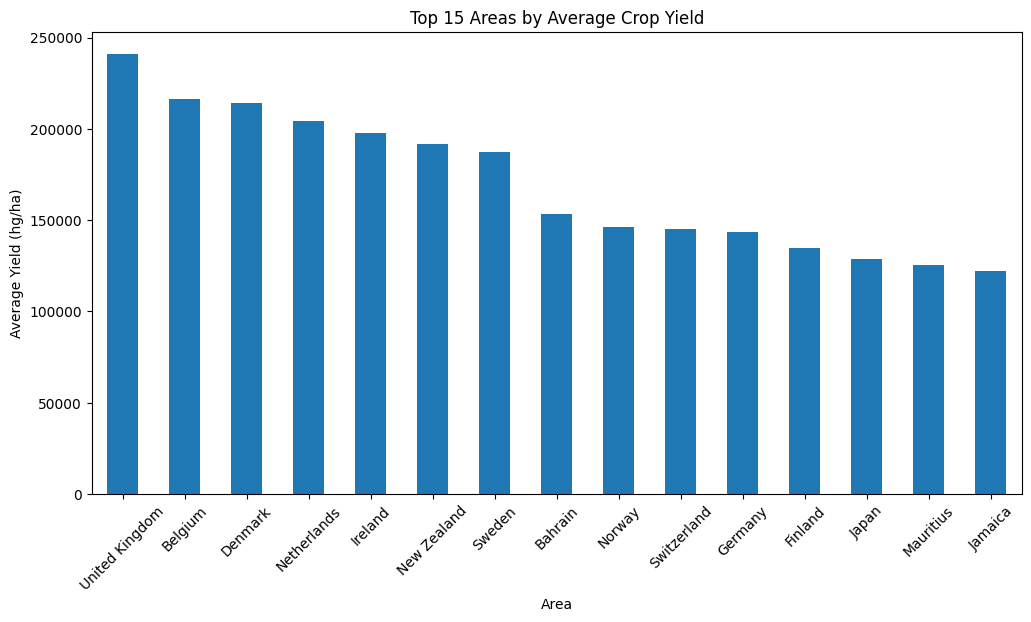

In [39]:
area_yield = (
    df.groupby("Area")["hg/ha_yield"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

area_yield.head(15).plot(kind="bar")

plt.title("Top 15 Areas by Average Crop Yield")
plt.xlabel("Area")
plt.ylabel("Average Yield (hg/ha)")
plt.xticks(rotation=45)

plt.show()

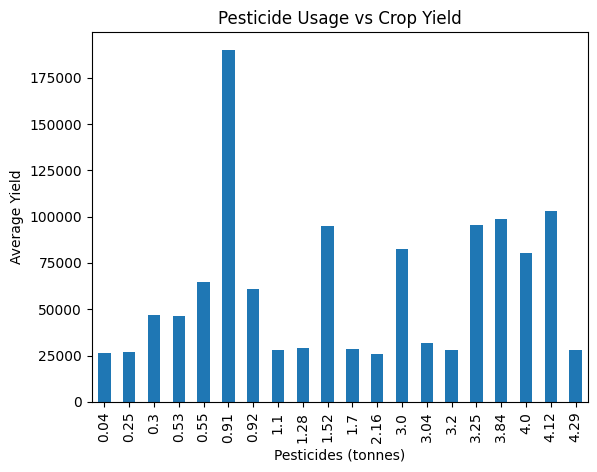

In [55]:
df.groupby("pesticides_tonnes")["hg/ha_yield"].mean().head(20).plot(kind="bar")
plt.title("Pesticide Usage vs Crop Yield")
plt.xlabel("Pesticides (tonnes)")
plt.ylabel("Average Yield")
plt.show()

# SPLITTING OF DATA

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [44]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (20745, 113)
X_test: (5187, 113)
y_train: (20745,)
y_test: (5187,)


In [45]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Model 1 — Linear Regression

In [47]:
lr_model = LinearRegression()

lr_model.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr_model.predict(
    X_test_scaled
)

Model 2 — Random Forest

In [48]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

Model 3 — XGBoost

In [49]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(
    X_test
)

In [51]:
def evaluate_model(y_test, prediction):

    mae = mean_absolute_error(
        y_test,
        prediction
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            prediction
        )
    )

    r2 = r2_score(
        y_test,
        prediction
    )

    return mae, rmse, r2

In [52]:
lr_mae, lr_rmse, lr_r2 = evaluate_model(
    y_test,
    lr_pred
)

rf_mae, rf_rmse, rf_r2 = evaluate_model(
    y_test,
    rf_pred
)

xgb_mae, xgb_rmse, xgb_r2 = evaluate_model(
    y_test,
    xgb_pred
)

In [53]:
print(f"Linear Regression R²: {lr_r2 * 100:.2f}%")
print(f"Random Forest R²: {rf_r2 * 100:.2f}%")
print(f"XGBoost R²: {xgb_r2 * 100:.2f}%")

Linear Regression R²: 74.87%
Random Forest R²: 98.47%
XGBoost R²: 92.45%


In [54]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "R2 Score (%)": [
        lr_r2 * 100,
        rf_r2 * 100,
        xgb_r2 * 100
    ],

    "MAE": [
        lr_mae,
        rf_mae,
        xgb_mae
    ],

    "RMSE": [
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ]
})

results["R2 Score (%)"] = results["R2 Score (%)"].round(2)
results["MAE"] = results["MAE"].round(2)
results["RMSE"] = results["RMSE"].round(2)

results

,Model,R2 Score (%),MAE,RMSE
0,Linear Regression,74.87,29920.74,42681.52
1,Random Forest,98.47,4004.63,10534.72
2,XGBoost,92.45,14073.93,23387.79
